In [2]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True #False if your computer sucks (mine does)

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

In [3]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [40]:
if(use_gpu):
    xp=cp
else:
    xp=np

m1 = 1e6
m2 = 10
a = 0.8 # 0.95
e0 = 0.4 # 0.6 just spin first
xI0 = 1.0
dist = 0.4
qS = xp.pi/4
phiS = 1.0
qK = 1 
phiK = xp.pi/3
Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 0.2

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.5

print(use_gpu)

True


In [5]:
SK_traj = EMRIInspiral(func=SuperKludgeFlux,use_gpu=use_gpu)
add_args= [chi2, evolve_1PA, evolve_primary, evolve_2PA,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p0_ = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1, m2, a, e0, xI0, *add_args])
print(p0_)

5.2684135797047835


In [6]:
filename= "rishav_CVBias"

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

# with longer signals we care less about this
t0 = 10000.0  # throw away on both ends when our orbital information is weird

In [7]:
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

print(use_gpu)
der_order = 8
Ndelta=8
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = True,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=True
                       )
                   

der_order = 12
Ndelta = 8
stability_plot = True

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
emri_kwargs = {"T":T, "dt":dt}
# sef.waveform_generator.backend.uses_cupy

True


In [8]:

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape:  (2, 631163)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.5, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  41.71176563349507


In [9]:
# got from Shubham's code
def cutlervallis(waveform_truth, waveform_approx, Fisher_truth, partial_approx, params_truth, PSD_func, dt, use_gpu=False):
    """
    Calculate best-fit param points using the Cutler-Vallisneri linear-bias approximation.
    params:
        waveform_truth (ndarray) : the time-series waveform from the true template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        waveform_approx (ndarray) : the time-series waveform from the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        partial_approx (ndarray) : the time-series partial derivative of the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        Fisher_truth (ndarray) : the Fisher matrix (log-mass units) at params_truth. ndarray of shape 'd x d'
        params_truth (ndarray) : the array of true params. ndarray of shape 'd'
        PSD_func (ndarray) : the frequency-domain LISA noise sensitivity curve. ndarray of shape 'N x L' where L is the length of the frequency series. 

    returns:
        CV_bias (ndarray): params_truth + np.linalg.inv(Fisher_truth) @ inner_product(partial_approx, waveform_truth - waveform_approx)
    """

#Equation 29 of cutler-vallisneri paper
    if use_gpu:
        xp = cp
    else:
        xp = np
        
    #waveform_truth = padding(waveform_truth, waveform_approx, use_gpu = use_gpu) #make waveform_truth the same length as waveform_approx
    delta_wave = waveform_truth - waveform_approx
    #truth contains 1 order PN and approx contains 0 order PN with deviations

    # calculate all the column-wise inner products
    inn_prods = []
    
    for j in range(len(Fisher_truth)):
        
        print("delta_wave.shape, partial_approx.shape: ", delta_wave.shape, partial_approx[j].shape)
                      
        inn_prod_j = inner_product(partial_approx[j], delta_wave, PSD=PSD_func, dt=dt, use_gpu = use_gpu) #should be a scalar
        if not use_gpu:
            inn_prod_j = xp.asarray(inn_prod_j)
        else:
            inn_prod_j = xp.asnumpy(inn_prod_j)
            
        print(f'inner_prod at j = {j}: ', inn_prod_j)
        inn_prods.append(inn_prod_j)
        
    inn_prods = np.array(inn_prods)
    # calculate all the param shifts
    delta_param_all = []
    
    for i in range(len(Fisher_truth)):
            
        delta_param_i = np.linalg.inv(Fisher_truth)[i,:]@inn_prods  #should be a scalars
        print(f"{param_names[i]} have delta {delta_param_i}")
        delta_param_all.append(delta_param_i)
        
    print('delta_param_all: ', delta_param_all)
    return params_truth + np.array(delta_param_all)


Body is not plunging, Fisher should be stable.
waveform shape:  (2, 631163)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.5, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 41.71176563349507
calculating stable deltas...
Gamma_ii for m1: 21.40761398570681
Gamma_ii for m1: 21.407613985754747
Gamma_ii for m1: 21.40761398573896
Gamma_ii for m1: 21.4076139859609
Gamma_ii for m1: 21.407613980792163
Gamma_ii for m1: 21.40761397905359
Gamma_ii for m1: 21.407613965520632
Gamma_ii for m1: 21.407613996954552
Gamma_ii for m1: 21.407613830555277
Gamma_ii for m1: 21.4076146099283
Gamma_ii for m1: 21.407615594112325
Gamma_ii for m1: 21.407616168579477
[np.float64(2.2392390716664495e-12), np.float64(7.375067393828681e-13), np.float64(1.0367413032292868e-11), np.float64(2.4144384117324324e-10), np.float64(8.121286805373664e-11), np.float64(6.321562920198744e-10), np.f

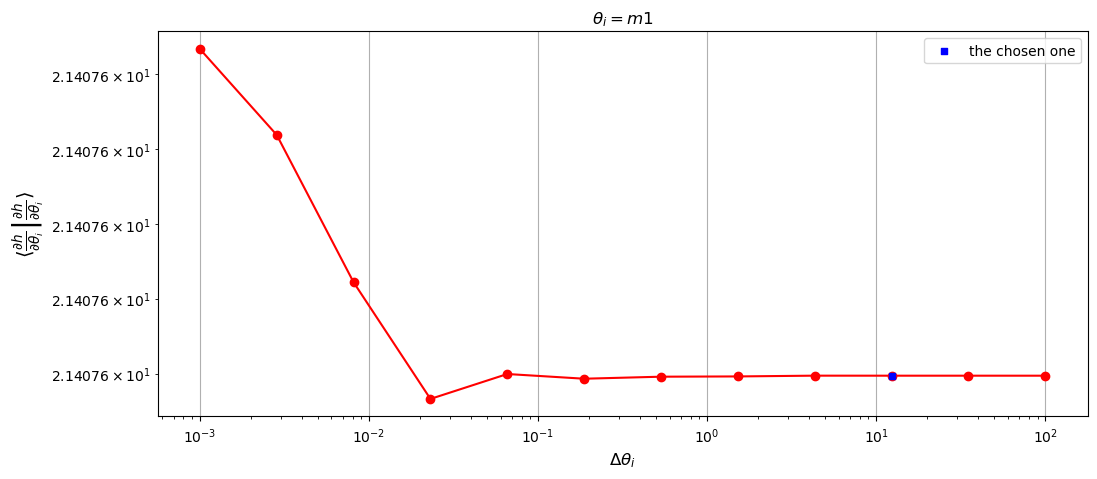

Gamma_ii for m2: 250672323.61392573
Gamma_ii for m2: 250672323.6021523
Gamma_ii for m2: 250672323.86563253
Gamma_ii for m2: 250672323.81330782
Gamma_ii for m2: 250672324.960119
Gamma_ii for m2: 250672325.513417
Gamma_ii for m2: 250672324.39727214
Gamma_ii for m2: 250672292.5960634
Gamma_ii for m2: 250672312.6468215
Gamma_ii for m2: 250672226.7049667
Gamma_ii for m2: 250672107.03629035
Gamma_ii for m2: 250673224.96156
[np.float64(4.696743977315705e-11), np.float64(1.0510942811871007e-09), np.float64(2.0873749235846393e-10), np.float64(4.5749413599995796e-09), np.float64(2.207256007968783e-09), np.float64(4.4526050828904855e-09), np.float64(1.2686367689530494e-07), np.float64(7.998792480063613e-08), np.float64(3.4284553950966856e-07), np.float64(4.773912732508996e-07), np.float64(4.4596915758943316e-06)]
0


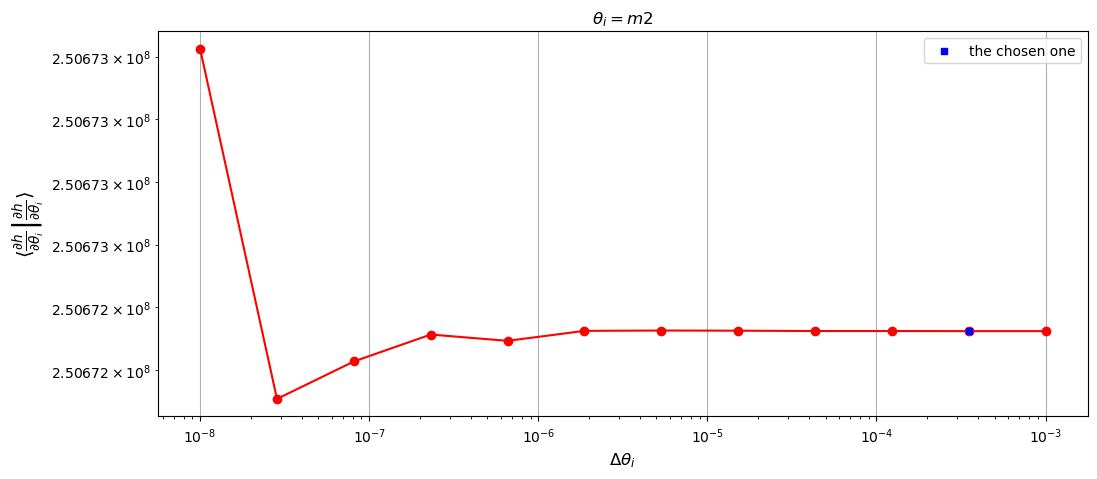

Gamma_ii for a: 41882488990.64592
Gamma_ii for a: 41882455123.43546
Gamma_ii for a: 41882381796.90792
Gamma_ii for a: 41882599391.93101
Gamma_ii for a: 41882587723.11644
Gamma_ii for a: 41881630473.889336
Gamma_ii for a: 41882493616.97279
Gamma_ii for a: 41886521683.43976
Gamma_ii for a: 41888852433.14586
Gamma_ii for a: 41928125494.255585
Gamma_ii for a: 41920493656.47721
Gamma_ii for a: 41826352263.087875
[np.float64(8.086252431247192e-07), np.float64(1.7507726255321941e-06), np.float64(5.195356215843402e-06), np.float64(2.786077747800072e-07), np.float64(2.2856064013576882e-05), np.float64(2.0608684176057747e-05), np.float64(9.616617243625786e-05), np.float64(5.5641288092585356e-05), np.float64(0.0009366758147846749), np.float64(0.00018205505500278166), np.float64(0.002250767477813652)]
3


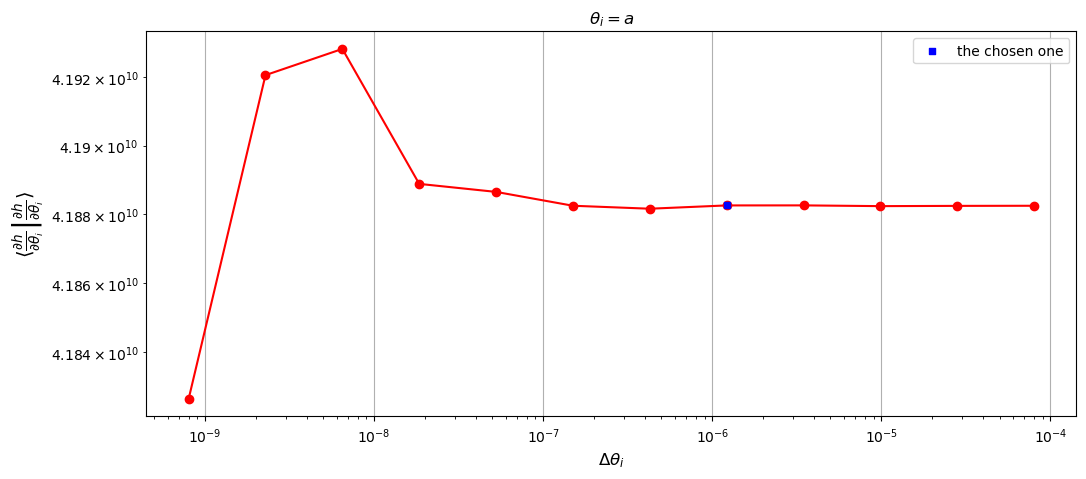

Gamma_ii for p0: 723659603258.8575
Gamma_ii for p0: 723659581612.6738
Gamma_ii for p0: 723659511005.4935
Gamma_ii for p0: 723659761611.4188
Gamma_ii for p0: 723660259254.8369
Gamma_ii for p0: 723659411283.4222
Gamma_ii for p0: 723662374848.5254
Gamma_ii for p0: 723666908545.538
Gamma_ii for p0: 723630488092.7991
Gamma_ii for p0: 723793088698.9174
Gamma_ii for p0: 723581621631.9921
Gamma_ii for p0: 723618576463.0071
[np.float64(2.991210821472417e-08), np.float64(9.75696155775607e-08), np.float64(3.463035235438941e-07), np.float64(6.876754826957759e-07), np.float64(1.17178247315123e-06), np.float64(4.095231707700346e-06), np.float64(6.2648947451325274e-06), np.float64(5.0330180027214396e-05), np.float64(0.00022465067525109314), np.float64(0.00029225046712538457), np.float64(5.106948911627873e-05)]
0


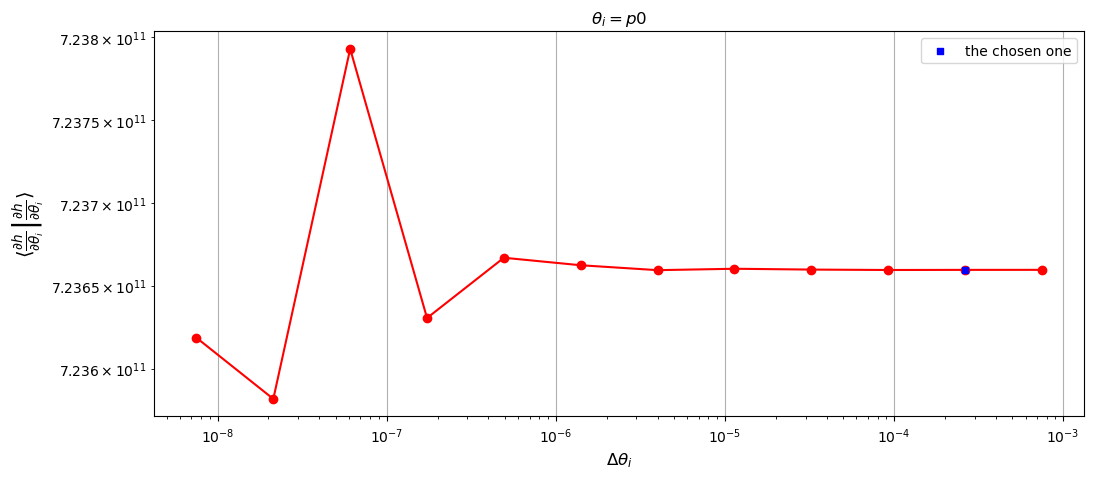

Gamma_ii for e0: 20518514407378.324
Gamma_ii for e0: 20518515501946.242
Gamma_ii for e0: 20518501621475.48
Gamma_ii for e0: 20518497762088.74
Gamma_ii for e0: 20518487433579.133
Gamma_ii for e0: 20518576319720.79
Gamma_ii for e0: 20518434083529.535
Gamma_ii for e0: 20517464699960.63
Gamma_ii for e0: 20516703466392.855
Gamma_ii for e0: 20521519713029.535
Gamma_ii for e0: 20489812585194.79
Gamma_ii for e0: 20543481246531.19
[np.float64(5.3345375685922644e-08), np.float64(6.764855942107827e-07), np.float64(1.880930459401538e-07), np.float64(5.033757794722153e-07), np.float64(4.331983870187907e-06), np.float64(6.9321172695182155e-06), np.float64(4.724675212469649e-05), np.float64(3.710311303277192e-05), np.float64(0.00023469249373484524), np.float64(0.0015474581674630122), np.float64(0.0026124423943709348)]
0


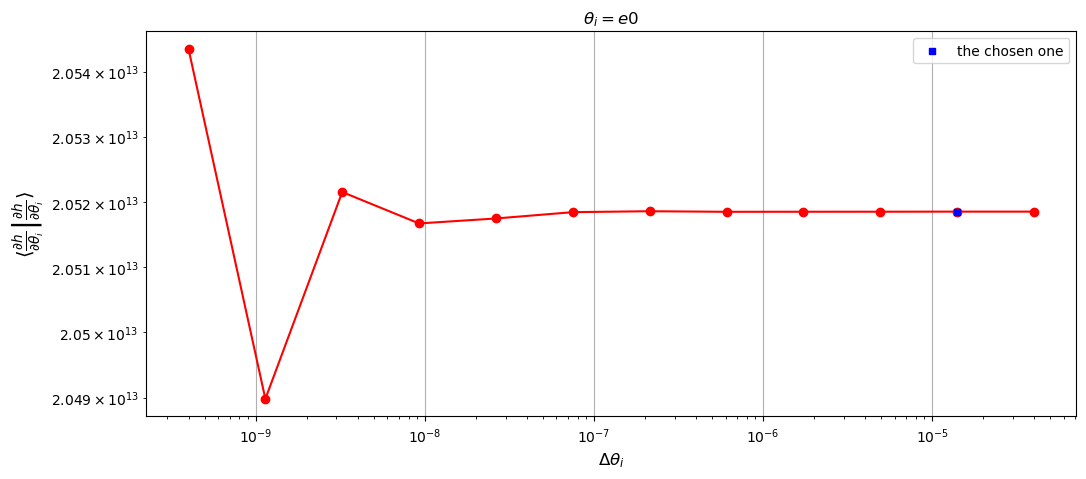

Gamma_ii for qS: 5356.219367909812
Gamma_ii for qS: 5356.219374659998
Gamma_ii for qS: 5356.219374661641
Gamma_ii for qS: 5356.219374661616
Gamma_ii for qS: 5356.2193746614485
Gamma_ii for qS: 5356.21937466272
Gamma_ii for qS: 5356.219374661557
Gamma_ii for qS: 5356.219374670537
Gamma_ii for qS: 5356.219374657405
Gamma_ii for qS: 5356.219374749776
Gamma_ii for qS: 5356.219374662775
Gamma_ii for qS: 5356.2193748413165
[np.float64(1.2602519670835174e-09), np.float64(3.0683151886539385e-13), np.float64(4.754445228683491e-15), np.float64(3.1243497217063916e-14), np.float64(2.3738265820350537e-13), np.float64(2.1717626598165185e-13), np.float64(1.6766211495693784e-12), np.float64(2.451765523464818e-12), np.float64(1.7245561455458342e-11), np.float64(1.624288291733239e-11), np.float64(3.333341549718162e-11)]
2


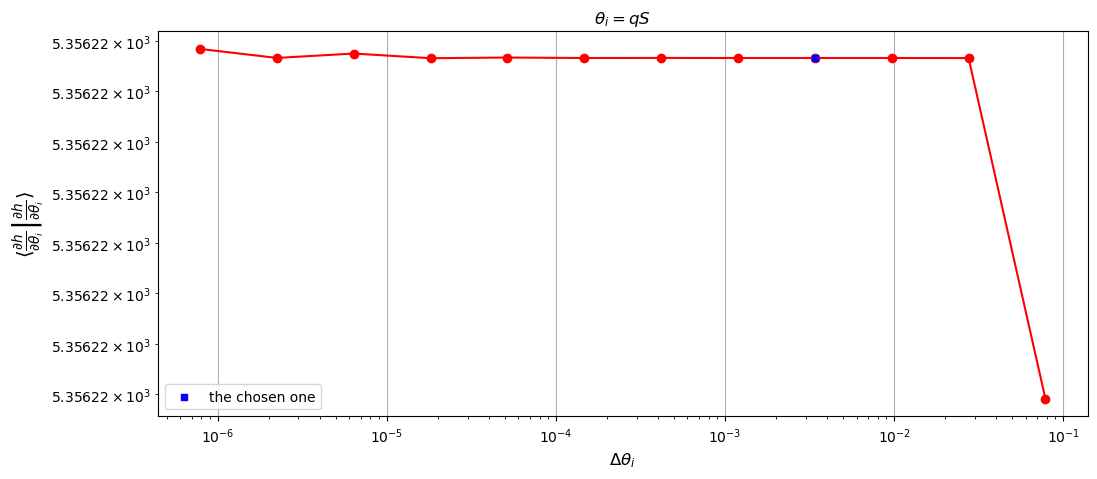

Gamma_ii for phiS: 103111.93247663214
Gamma_ii for phiS: 103111.93247530742
Gamma_ii for phiS: 103111.93247530708
Gamma_ii for phiS: 103111.9324753071
Gamma_ii for phiS: 103111.93247530708
Gamma_ii for phiS: 103111.9324753071
Gamma_ii for phiS: 103111.93247530707
Gamma_ii for phiS: 103111.9324753072
Gamma_ii for phiS: 103111.93247530721
Gamma_ii for phiS: 103111.93247530679
Gamma_ii for phiS: 103111.93247530697
Gamma_ii for phiS: 103111.93247531104
[np.float64(1.2847388455418418e-11), np.float64(3.2459293722633804e-15), np.float64(1.411273640114513e-16), np.float64(1.4112736401145133e-16), np.float64(1.411273640114513e-16), np.float64(2.822547280229027e-16), np.float64(1.2701462761030605e-15), np.float64(1.4112736401145115e-16), np.float64(4.0926935563321e-15), np.float64(1.6935283681374178e-15), np.float64(3.9515661923204855e-14)]
7


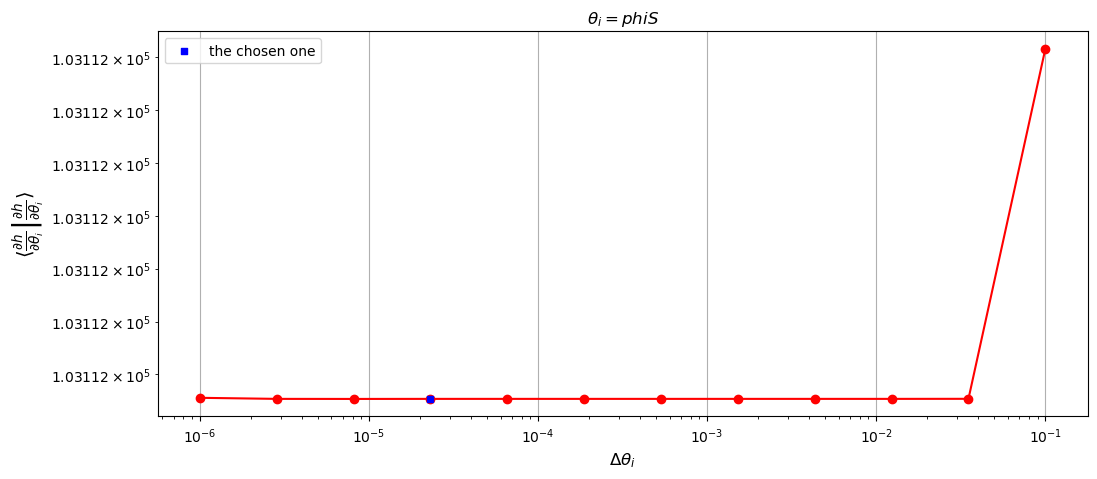

Gamma_ii for dev0p: 12301758905.187817
Gamma_ii for dev0p: 12301749433.482944
Gamma_ii for dev0p: 12301754839.644398
Gamma_ii for dev0p: 12301920705.068491
Gamma_ii for dev0p: 12302000726.443201
Gamma_ii for dev0p: 12301847697.137411
Gamma_ii for dev0p: 12300370090.938698
Gamma_ii for dev0p: 12309143862.156546
Gamma_ii for dev0p: 12235762689.162737
Gamma_ii for dev0p: 12218869053.025131
Gamma_ii for dev0p: 12335142554.03693
Gamma_ii for dev0p: 11120219456.950924
[np.float64(7.699477967215971e-07), np.float64(4.394626233181659e-07), np.float64(1.3482888409848762e-05), np.float64(6.504744755710893e-06), np.float64(1.2439538316309735e-05), np.float64(0.00012012697079755425), np.float64(0.0007127848464605297), np.float64(0.0059972700401261245), np.float64(0.0013825859058063286), np.float64(0.009426198400418645), np.float64(0.1092535180433506)]
1


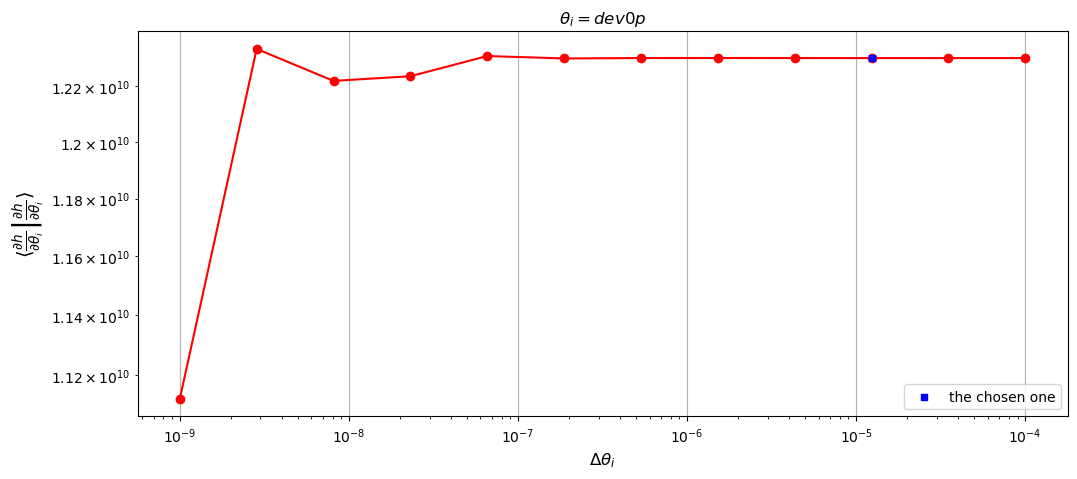

Gamma_ii for dev0e: 2256618890.6316056
Gamma_ii for dev0e: 2256646191.777833
Gamma_ii for dev0e: 2256607886.619598
Gamma_ii for dev0e: 2256623327.1612177
Gamma_ii for dev0e: 2256682975.183993
Gamma_ii for dev0e: 2256370805.2357574
Gamma_ii for dev0e: 2256147454.504318
Gamma_ii for dev0e: 2269120585.260478
Gamma_ii for dev0e: 2281903675.822694
Gamma_ii for dev0e: 2235579730.1112585
Gamma_ii for dev0e: 2150668335.919414
Gamma_ii for dev0e: 2413727957.0344296
[np.float64(1.2098106618056665e-05), np.float64(1.6974662927574127e-05), np.float64(6.842321194650389e-06), np.float64(2.6431724540444116e-05), np.float64(0.00013835046416623648), np.float64(9.899651327895338e-05), np.float64(0.005717250480397261), np.float64(0.005601941351712457), np.float64(0.020721222816387722), np.float64(0.039481398769719976), np.float64(0.10898478444862426)]
2


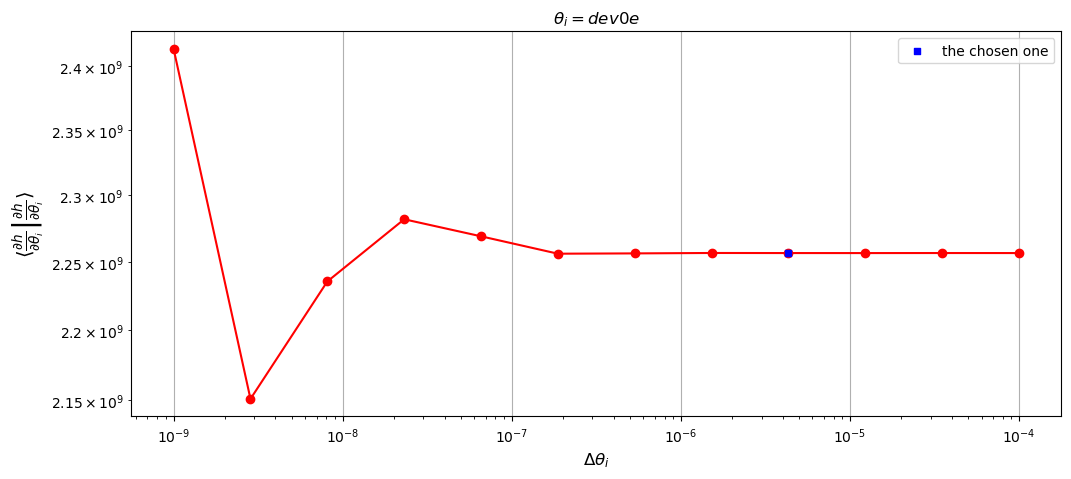

stable deltas: {'m1': 12.32846739442066, 'm2': 0.0003511191734215131, 'a': 1.215928866362347e-06, 'p0': 0.00026333938006613484, 'e0': 1.4044766936860542e-05, 'qS': 0.00339980115994862, 'phiS': 2.310129700083158e-05, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': 1.2328467394420658e-05, 'dev0e': 4.328761281083061e-06}
Time taken to compute stable deltas is 51.9253203868866 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 4.8359246253967285 seconds


In [10]:
#initialize the 0PA (approximate) model
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}


param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}
der_order = 8
Ndelta = 12

Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,
            )


In [11]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J

In [12]:
Fisher[-1].shape

(11, 11)

In [13]:
fisher_=Fisher[-1].copy()
fisher_
# sef.deltas["Phi_phi0"] = 1e-5
# sef.deltas["Phi_r0"] = 1e-5
sef.deltas

{'m1': 12.32846739442066,
 'm2': 0.0003511191734215131,
 'a': 1.215928866362347e-06,
 'p0': 0.00026333938006613484,
 'e0': 1.4044766936860542e-05,
 'qS': 0.00339980115994862,
 'phiS': 2.310129700083158e-05,
 'Phi_phi0': 0.0,
 'Phi_r0': 0.0,
 'dev0p': 1.2328467394420658e-05,
 'dev0e': 4.328761281083061e-06}

In [14]:
#in this code cell, we are transfroming fisher for numerical stability and will remove parameters that are causing problem

print("Transforming to log-mass")
Fisher_transform = logmasstransform(fisher_, m1)
print("Checking log-mass Fisher positive-definiteness...")
check_flag = True
rows_to_remove = []
for j in range(len(param_names)):
    if param_names[j] in []:#'dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']:
            rows_to_remove.append(j)

rows_to_remove = np.array(rows_to_remove)
    
if len(rows_to_remove) > 0:
    Fisher_transformed = np.delete(np.delete(Fisher_transform,rows_to_remove,axis=0),rows_to_remove,axis=1)
    #Fisher = np.delete(np.delete(Fisher,rows_to_remove,axis=0),rows_to_remove,axis=1)

if (np.linalg.eigvals(Fisher_transform) < 0.0).any():
    check_flag = False
    print('positive definiteness failed for: ', i)
        
if check_flag:
    print("positive-definiteness check passed!")
pd.DataFrame(Fisher_transform)

Transforming to log-mass
Checking log-mass Fisher positive-definiteness...
positive-definiteness check passed!


,0,1,2,3,4,5,6,7,8,9,10
0,2.140761e+13,-7.105573e+10,-3.769154e+11,3.933035e+12,2.094794e+13,-2.735935e+08,1.262623e+09,-3.311320e+08,-3.564958e+08,-4.965685e+11,-2.142096e+11
1,-7.105573e+10,2.506723e+08,1.015913e+09,-1.309767e+10,-6.898063e+10,8.156336e+05,-3.763839e+06,9.870968e+05,1.035339e+06,1.755839e+09,7.516186e+08
2,-3.769154e+11,1.015913e+09,4.188259e+10,-6.308676e+10,-3.783609e+11,3.670341e+06,-1.690255e+07,4.416628e+06,1.186240e+07,6.807701e+09,3.355290e+09
3,3.933035e+12,-1.309767e+10,-6.308676e+10,7.236596e+11,3.846838e+12,-5.044933e+07,2.328277e+08,-6.106359e+07,-6.449992e+07,-9.158354e+10,-3.943371e+10
4,2.094794e+13,-6.898063e+10,-3.783609e+11,3.846838e+12,2.051852e+13,-2.710883e+08,1.251062e+09,-3.280995e+08,-3.544603e+08,-4.819127e+11,-2.081095e+11
5,-2.735935e+08,8.156336e+05,3.670341e+06,-5.044933e+07,-2.710883e+08,5.356219e+03,-2.226894e+04,5.841132e+03,5.835733e+03,5.697268e+06,2.461191e+06
6,1.262623e+09,-3.763839e+06,-1.690255e+07,2.328277e+08,1.251062e+09,-2.226894e+04,1.031119e+05,-2.696129e+04,-2.692622e+04,-2.629320e+07,-1.135824e+07
7,-3.311320e+08,9.870968e+05,4.416628e+06,-6.106359e+07,-3.280995e+08,5.841132e+03,-2.696129e+04,7.073114e+03,7.059534e+03,6.895691e+06,2.978674e+06
8,-3.564958e+08,1.035339e+06,1.186240e+07,-6.449992e+07,-3.544603e+08,5.835733e+03,-2.692622e+04,7.059534e+03,8.963091e+03,7.183348e+06,3.173695e+06
9,-4.965685e+11,1.755839e+09,6.807701e+09,-9.158354e+10,-4.819127e+11,5.697268e+06,-2.629320e+07,6.895691e+06,7.183348e+06,1.230175e+10,5.261779e+09


In [15]:
delats=sef.deltas
param_name = sef.param_names

In [16]:
parameters = {}
for i in range(len(param_names_com)):
    parameters[param_names_com[i]] = pars_list_com[i]


order = 8 #order of finite-difference derivative
kind = "central" #kind of finite-difference derivative
parameters

{'m1': 1000000.0,
 'm2': 10,
 'a': 0.8,
 'p0': 7.5,
 'e0': 0.4,
 'xI0': 1.0,
 'dist': 0.4,
 'qS': 0.7853981633974483,
 'phiS': 1.0,
 'qK': 1,
 'phiK': 1.0471975511965976,
 'Phi_phi0': 0.9,
 'Phi_theta0': 0.5,
 'Phi_r0': 0.4,
 'chi2': 0.0,
 'evolve_1PA': False,
 'evolve_primary': False,
 'evolve_2PA': False,
 'deviation_included': True,
 'dev0p': 0.0,
 'dev0e': 0.0,
 'dev1p': 0.0,
 'dev1e': 0.0,
 'dev2p': 0.0,
 'dev2e': 0.0}

In [17]:
# del sef
sef.wave_params_list

[1000000.0,
 10,
 0.8,
 7.5,
 0.4,
 1.0,
 0.4,
 0.7853981633974483,
 1.0,
 1,
 1.0471975511965976,
 0.9,
 0.5,
 0.4,
 0.0,
 False,
 False,
 False,
 True,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [18]:
sef.waveform_derivative_kwargs

{'parameters': {'m1': 1000000.0,
  'm2': 10,
  'a': 0.8,
  'p0': 7.5,
  'e0': 0.4,
  'xI0': 1.0,
  'dist': 0.4,
  'qS': 0.7853981633974483,
  'phiS': 1.0,
  'qK': 1,
  'phiK': 1.0471975511965976,
  'Phi_phi0': 0.9,
  'Phi_theta0': 0.5,
  'Phi_r0': 0.4,
  'chi2': 0.0,
  'evolve_1PA': False,
  'evolve_primary': False,
  'evolve_2PA': False,
  'deviation_included': True,
  'dev0p': 0.0,
  'dev0e': 0.0,
  'dev1p': 0.0,
  'dev1e': 0.0,
  'dev2p': 0.0,
  'dev2e': 0.0},
 'order': 8,
 'dt': 10.0,
 'T': 0.2}

In [19]:
print(f"Calculating Cutler-Vallisneri Biases")
removed_params = []
print(f'calculating derivatives at {param_names}...')
#Fisher = np.zeros((sef.npar,sef.npar), dtype=np.float64)
dtv = []

for k in range(sef.npar):
        temp=sef.derivative(*sef.wave_params_list,
                             param_to_vary=sef.param_names[k],
                               delta=sef.deltas[sef.param_names[k]],
                               kind=kind, **sef.waveform_derivative_kwargs,use_gpu=use_gpu)
        print(temp)
        print("\n",temp.shape)
        print(f"calculting derivative for {sef.param_names[k]}\n")
        dtv_=np.vstack([temp.real,temp.imag])
        print(dtv_)
        dtv.append(dtv_)
        

print("Finished derivatives")
if sef.use_gpu:
        dtv = cp.asnumpy(cp.asarray(dtv)) #h5py only stores numpy
          
#Jacobian transform to log-masses
for k in range(sef.npar):
    if sef.param_names[k] == 'm1':
        dtv[k] *= m1 #to obtain \partial_{log m1}h

Calculating Cutler-Vallisneri Biases
calculating derivatives at ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0', 'dev0p', 'dev0e']...
[1.51947754e-32+4.48087569e-33j 1.22672275e-28-1.68206665e-28j
 3.12745347e-28-2.42841672e-28j ... 1.42256706e-23+2.92541118e-23j
 1.02598427e-23+2.97972931e-23j 6.38462127e-24+2.98534316e-23j]

 (631163,)
calculting derivative for m1

[[ 1.51947754e-32  1.22672275e-28  3.12745347e-28 ...  1.42256706e-23
   1.02598427e-23  6.38462127e-24]
 [ 4.48087569e-33 -1.68206665e-28 -2.42841672e-28 ...  2.92541118e-23
   2.97972931e-23  2.98534316e-23]]
[ 1.51947700e-22+4.48089246e-23j  1.32146299e-22+8.23246750e-23j
  1.03960110e-22+1.11405943e-22j ... -7.81706440e-20-1.46883792e-19j
 -5.80857071e-20-1.51099569e-19j -3.82649794e-20-1.52777467e-19j]

 (631163,)
calculting derivative for m2

[[ 1.51947700e-22  1.32146299e-22  1.03960110e-22 ... -7.81706440e-20
  -5.80857071e-20 -3.82649794e-20]
 [ 4.48089246e-23  8.23246750e-23  1.11405943e-22 ... -

In [20]:
params_truth_in = np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,dev_0_p,dev_0_e])
#params_truth_in_transformed = np.array([np.log(m1), m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,dev_0_p,dev_0_e])

# param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

params_truth_in_considered = np.array([np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0,Phi_r0,dev_0_p,dev_0_e])
#params_truth_in_considered = np.array([np.log(m1), m2, a, p0, e0, dev_0_p, dev_0_e])
print(params_truth_in_considered)
waveform_approx = sef.waveform
waveform_approx

[13.81551056 10.          0.8         7.5         0.4         0.78539816
  1.          0.9         0.4         0.          0.        ]


array([[ 7.59746097e-22,  6.60737442e-22,  5.19804078e-22, ...,
        -3.20722338e-22, -3.39033645e-22, -3.51440164e-22],
       [-2.24046863e-22, -4.11628370e-22, -5.57036538e-22, ...,
        -2.11679210e-22, -1.67202025e-22, -1.22292149e-22]],
      shape=(2, 631163))

In [21]:
#initializing the 1PA (True GR model in our analysis)
evolve_1PA = True 
evolve_primary = False
evolve_2PA = False #for approximate model
dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
deviation_included=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
print(add_args)
waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
waveform_true= xp.asarray(waveform_true)

[0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


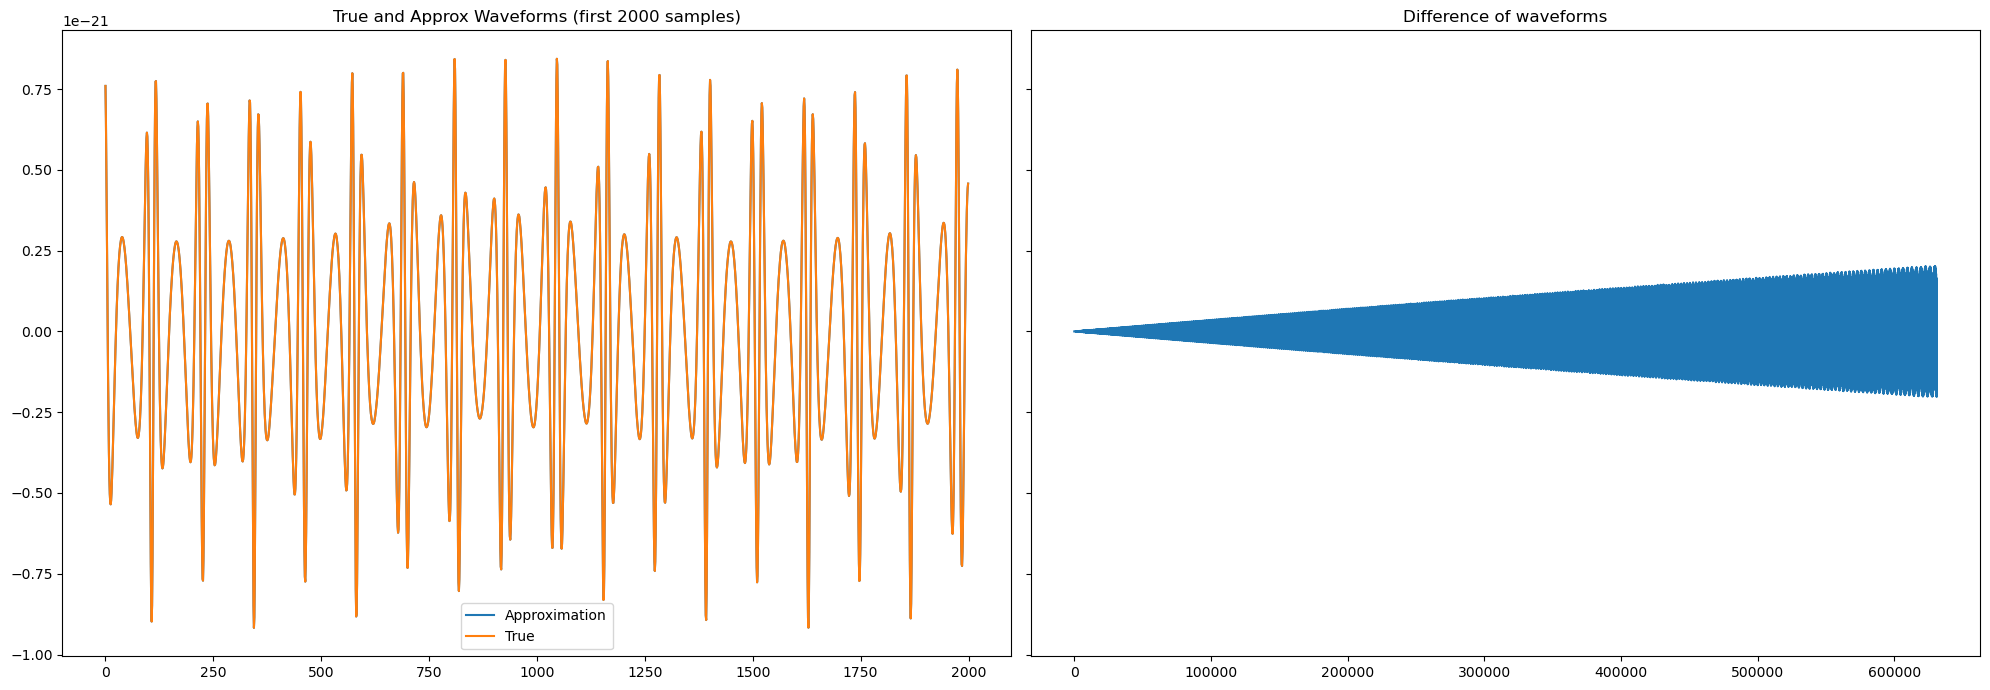

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# Plot the first 2000 samples of both waveforms
axs[0].plot(waveform_approx[0][0:2000].get(), label="Approximation")
axs[0].plot(waveform_true[0][0:2000].get(), label="True")
axs[0].set_title("True and Approx Waveforms (first 2000 samples)")
axs[0].legend()

# Plot the difference
axs[1].plot(((waveform_true[0] - waveform_approx[0])[0:]).get())
axs[1].set_title("Difference of waveforms")

plt.tight_layout()

In [23]:
biased_params = cutlervallis(waveform_truth=waveform_true, waveform_approx=waveform_approx,
                                 Fisher_truth=Fisher_transform, partial_approx=dtv,
                                 params_truth=params_truth_in_considered, PSD_func = sef.PSD_funcs, dt = dt,
                                  use_gpu=use_gpu)
print(biased_params)

if use_gpu:
        biased_params = cp.asnumpy(cp.asarray(biased_params))

#prior box on chi2
# if 'chi2' not in removed_params:
#     index_chi2 = np.where(param_names == 'chi2')
        
#     if biased_params[index_chi2] > 1.0:
#         biased_params[index_chi2] = 1.0
#     elif biased_params[index_chi2] < -1.0:
#         biased_params[index_chi2] = -1.0

#prior box on cyclic parameters (phases and such)
cyclic_priors = {'qS' : np.pi, 'phiS' : 2 * np.pi, 'qK' : np.pi, 'phiK' : 2 * np.pi, 'Phi_phi0' : 2 * np.pi, 'Phi_r0' : 2 * np.pi}
param_names_in = np.array(param_names)
for param in list(cyclic_priors.keys()):
    if param not in removed_params:
        print(f"modulo {cyclic_priors[param]} for param {param}")
            
        index = np.where(param_names_in == param) 
        biased_params[index] %= cyclic_priors[param]


print('biased params: ', biased_params)

#calculate the sigma contour as the Mahalanobis distance between the true and biased params (https://en.wikipedia.org/wiki/Mahalanobis_distance):
    
sigma_contour = np.sqrt((biased_params - params_truth_in_considered)@Fisher_transform@(biased_params - params_truth_in_considered))
sigma_contour /= np.sqrt(len(params_truth_in_considered)) #scaled Mahalonobis distance for dimensional generality
    
print('sigma contours: ', sigma_contour)

delta_wave.shape, partial_approx.shape:  (2, 631163) (2, 631163)
inner_prod at j = 0:  -2735.4241725469587
delta_wave.shape, partial_approx.shape:  (2, 631163) (2, 631163)
inner_prod at j = 1:  8.945617256956798
delta_wave.shape, partial_approx.shape:  (2, 631163) (2, 631163)
inner_prod at j = 2:  56.179535092304484
delta_wave.shape, partial_approx.shape:  (2, 631163) (2, 631163)
inner_prod at j = 3:  -501.14431476372994
delta_wave.shape, partial_approx.shape:  (2, 631163) (2, 631163)
inner_prod at j = 4:  -2681.741403292819
delta_wave.shape, partial_approx.shape:  (2, 631163) (2, 631163)
inner_prod at j = 5:  0.2187860944233345
delta_wave.shape, partial_approx.shape:  (2, 631163) (2, 631163)
inner_prod at j = 6:  0.016245455738714387
delta_wave.shape, partial_approx.shape:  (2, 631163) (2, 631163)
inner_prod at j = 7:  0.04313560630499569
delta_wave.shape, partial_approx.shape:  (2, 631163) (2, 631163)
inner_prod at j = 8:  0.04756921179986871
delta_wave.shape, partial_approx.shape:  

In [24]:
print(sigma_contour)

0.003987052040278775


In [25]:
biased_params

array([1.38155263e+01, 9.99951690e+00, 8.00010357e-01, 7.49993942e+00,
       3.99995922e-01, 7.85809592e-01, 1.00054734e+00, 9.01738456e-01,
       4.00006609e-01, 5.99205007e-05, 6.81916438e-05])

In [26]:
params_truth_in_considered

array([13.81551056, 10.        ,  0.8       ,  7.5       ,  0.4       ,
        0.78539816,  1.        ,  0.9       ,  0.4       ,  0.        ,
        0.        ])

# plot ig

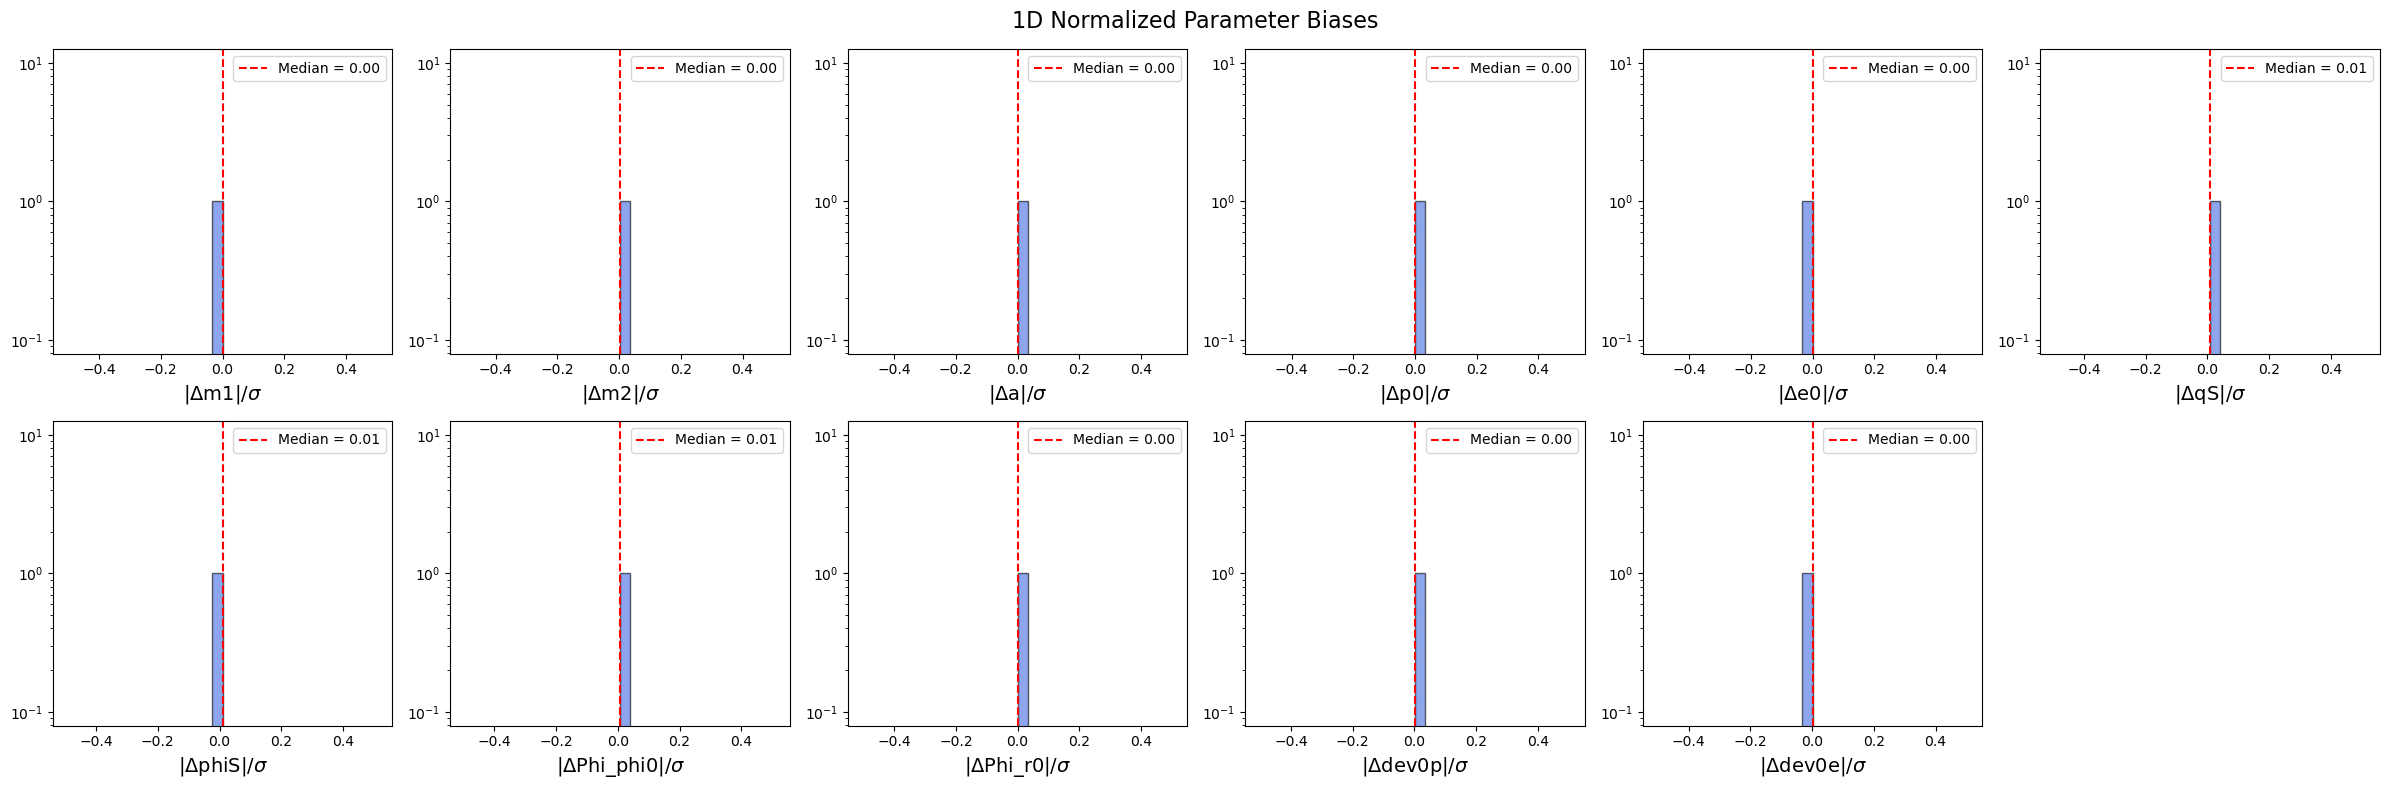

In [27]:
#used gpt (boring part)

# === PARAMETERS ===
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']


params_truth_in_considered = np.array([
    np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_0_p, dev_0_e
])
truevals_i = params_truth_in_considered

Fisher_transformed = Fisher_transform.copy()

# === REMOVE PARAMETERS IF SPECIFIED ===
rows_to_remove = [i for i, name in enumerate(param_names) if name in removed_params]
rows_to_remove = np.array(rows_to_remove)

if len(rows_to_remove) > 0:
    Fisher_transformed = np.delete(Fisher_transformed, rows_to_remove, axis=0)
    Fisher_transformed = np.delete(Fisher_transformed, rows_to_remove, axis=1)
   # param_names_plot = np.delete(param_names_plot, rows_to_remove, axis=0)
    truevals_i = np.delete(truevals_i, rows_to_remove, axis=0)

# === COMPUTE SIGMAS ===
covariance = np.linalg.inv(Fisher_transformed)
sigmas_params = np.sqrt(np.diag(covariance))

# === COMPUTE NORMALIZED BIASES ===
sigmabias_1D = np.abs(biased_params - truevals_i) / sigmas_params

# === PLOT ===
n_params = len(param_names)
ncols = int(np.ceil(n_params / 2))

fig, axs = plt.subplots(2, ncols, figsize=(4 * ncols, 8))
axs = axs.flatten()

for i, name in enumerate(param_names):
    axs[i].hist(sigmabias_1D[i], bins=30, histtype='stepfilled',
                color='royalblue', alpha=0.6, edgecolor='k')
    axs[i].set_xlabel(r"$|\Delta $" + rf"{name}" + r"$|/\sigma$", fontsize=14)
    axs[i].set_yscale('log')
    axs[i].axvline(np.median(sigmabias_1D[i]), color='r', linestyle='--',
                   label=f"Median = {np.median(sigmabias_1D[i]):.2f}")
    axs[i].legend(fontsize=10)

# Hide any unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle("1D Normalized Parameter Biases", fontsize=16)
plt.show()



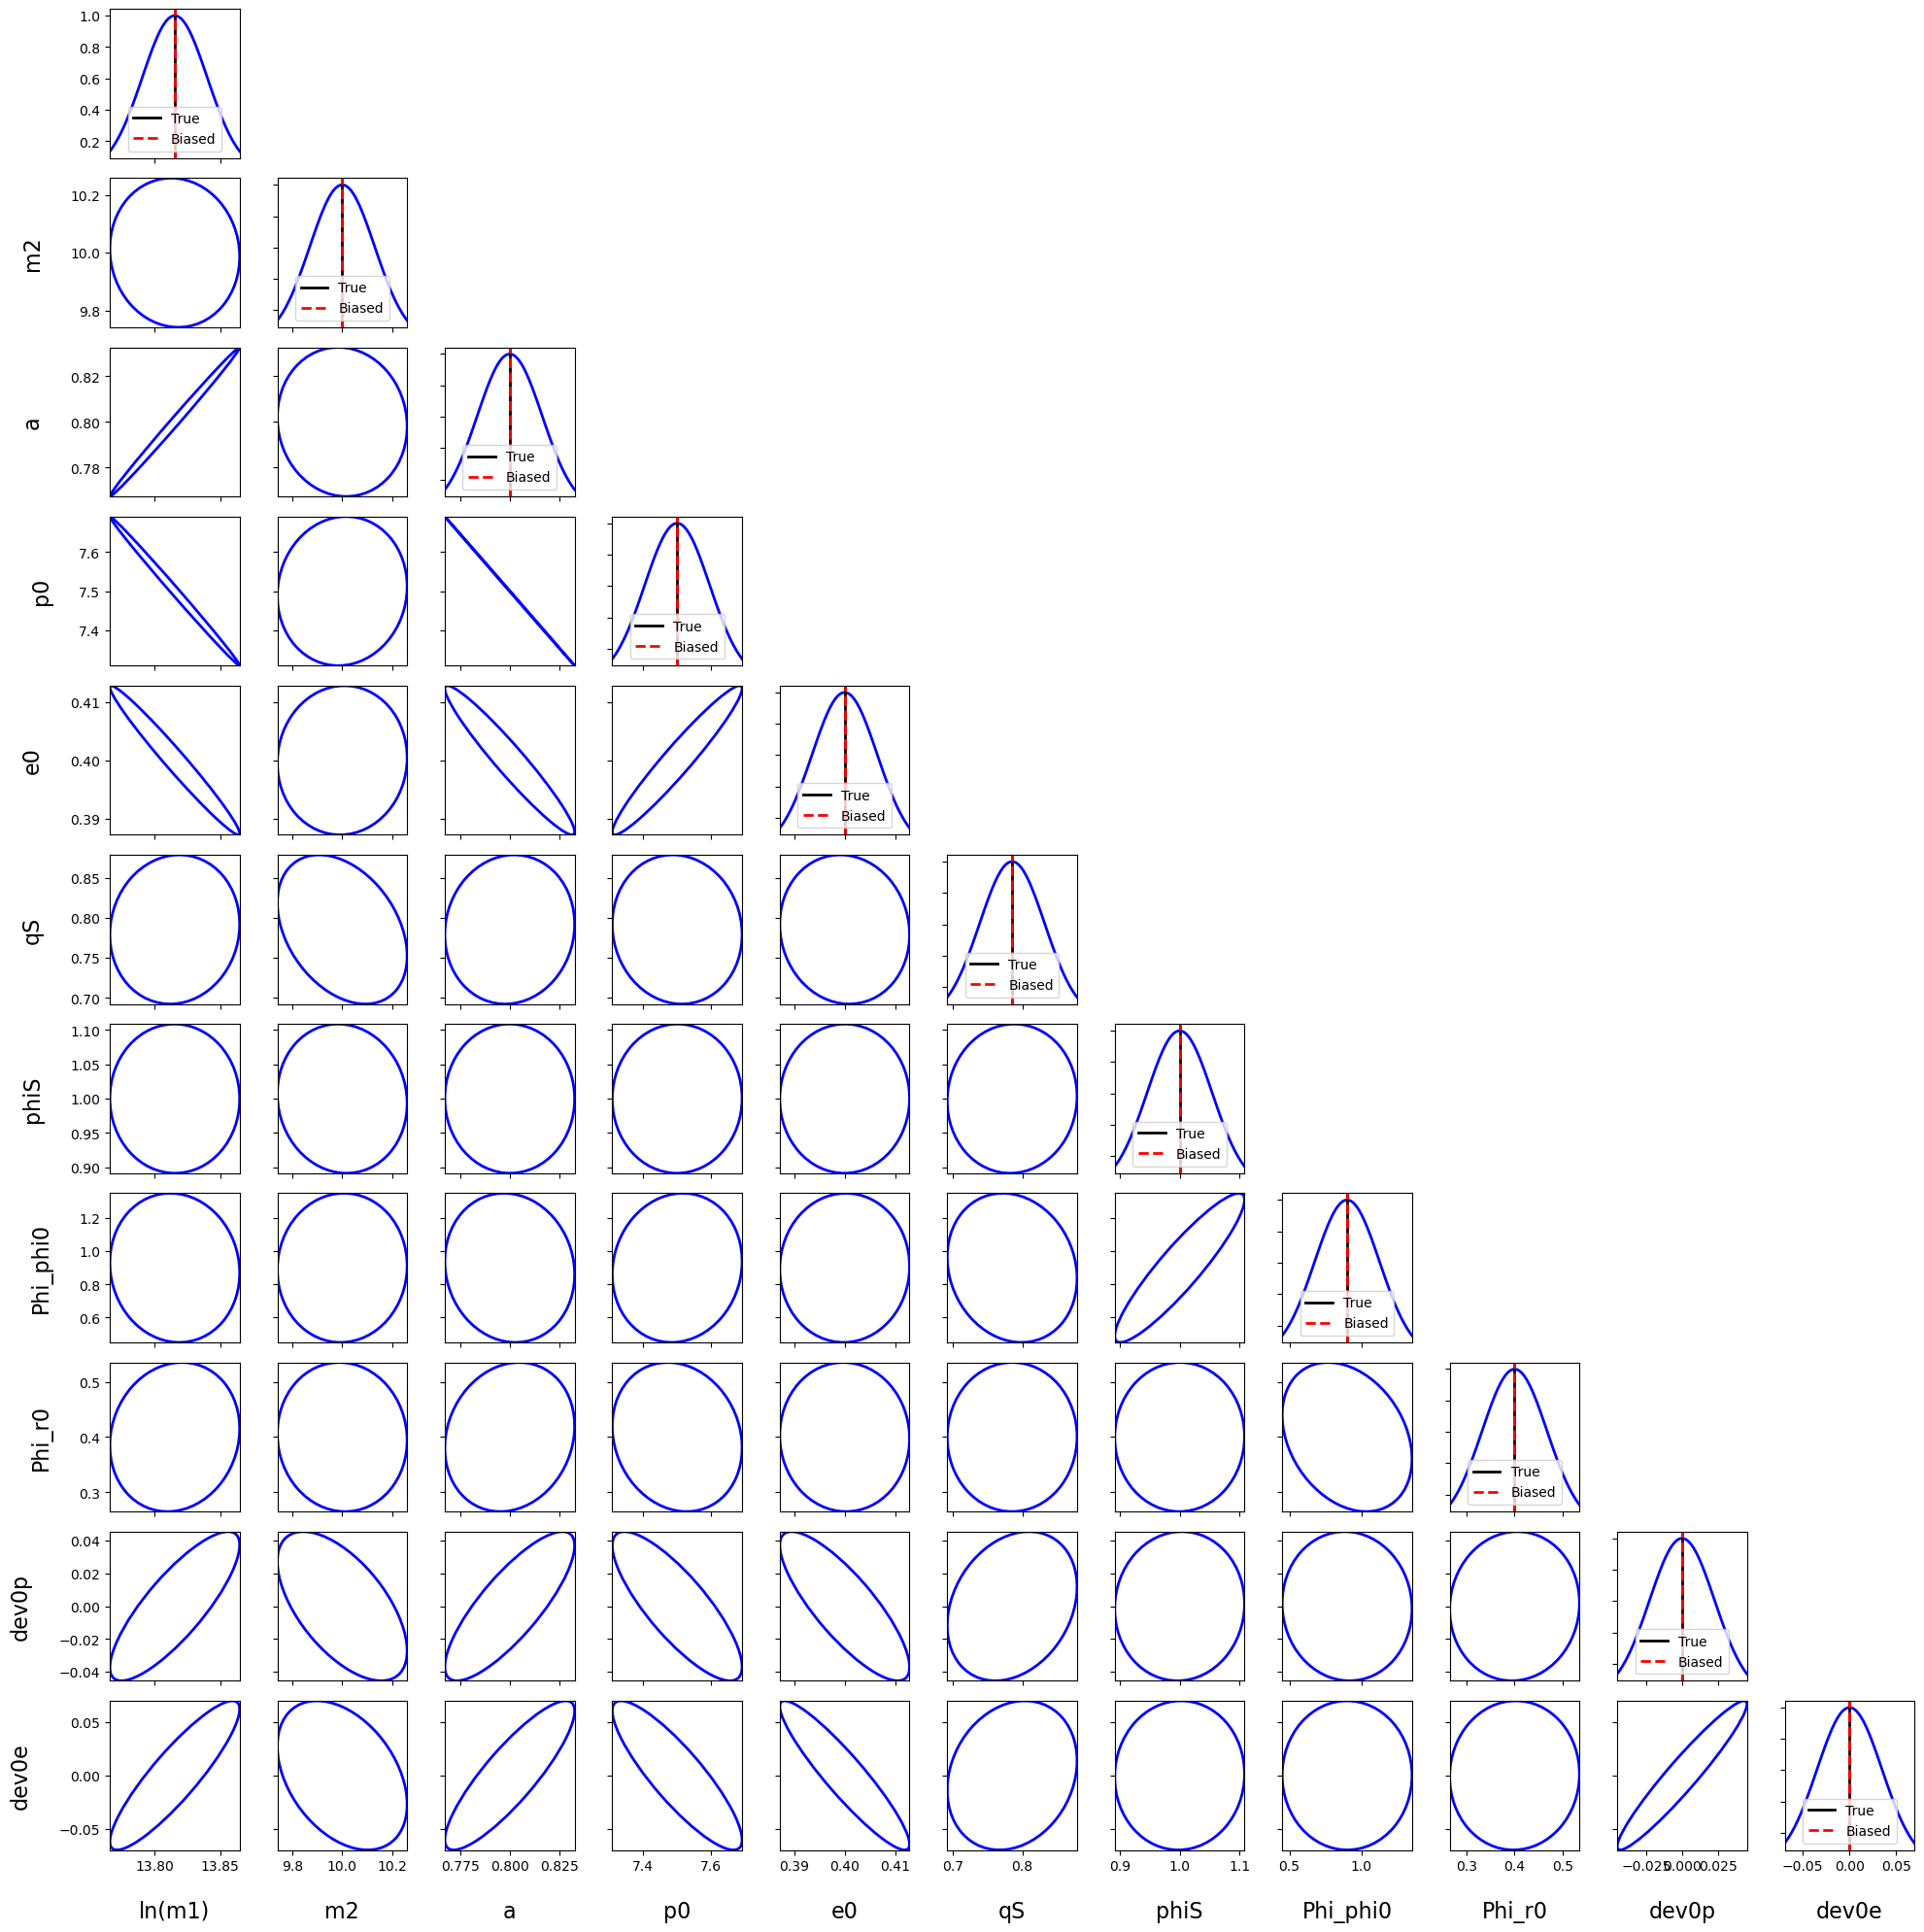

In [28]:
from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = params_truth_in_considered
# param_names_plot = [
#     r'$\log{m_1}$', r'$m_2$', r'$a$', r'$p_0$', r'$e_0$',
#     r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
#     r'dev0_p', r'dev0_e'
# ]
param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = params_truth_in_considered[i]

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)
# === ADD TRUE AND BIASED PARAMETER LINES ===
for i in range(len(param_names)):
    # Diagonal subplot (1D)
    ax = axs[i, i]
    ax.axvline(params_truth_in_considered[i], color='k', linestyle='-', lw=2, label='True')
    ax.axvline(biased_params[i], color='r', linestyle='--', lw=2, label='Biased')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


In [29]:
biased_params

array([1.38155263e+01, 9.99951690e+00, 8.00010357e-01, 7.49993942e+00,
       3.99995922e-01, 7.85809592e-01, 1.00054734e+00, 9.01738456e-01,
       4.00006609e-01, 5.99205007e-05, 6.81916438e-05])

In [30]:
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
dev_0_p=biased_params[9]
dev_0_e=biased_params[10]
# param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
deviation_included=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

pars_list = [np.exp(biased_params[0]), biased_params[1], biased_params[2], biased_params[3], \
             biased_params[4], xI0, dist, biased_params[5], biased_params[6], qK, phiK, biased_params[7], Phi_theta0,\
               biased_params[8]]

superkludge_wave_biased = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)

waveform_biased = superkludge_wave_biased(*pars_list, *add_args, dt=dt, T=T)


In [31]:
deviation=params_truth_in_considered-biased_params
print("Higher",biased_params)
print("\nTrue",params_truth_in_considered)
print("\nlower",params_truth_in_considered+deviation)

Higher [1.38155263e+01 9.99951690e+00 8.00010357e-01 7.49993942e+00
 3.99995922e-01 7.85809592e-01 1.00054734e+00 9.01738456e-01
 4.00006609e-01 5.99205007e-05 6.81916438e-05]

True [13.81551056 10.          0.8         7.5         0.4         0.78539816
  1.          0.9         0.4         0.          0.        ]

lower [ 1.38154948e+01  1.00004831e+01  7.99989643e-01  7.50006058e+00
  4.00004078e-01  7.84986735e-01  9.99452663e-01  8.98261544e-01
  3.99993391e-01 -5.99205007e-05 -6.81916438e-05]


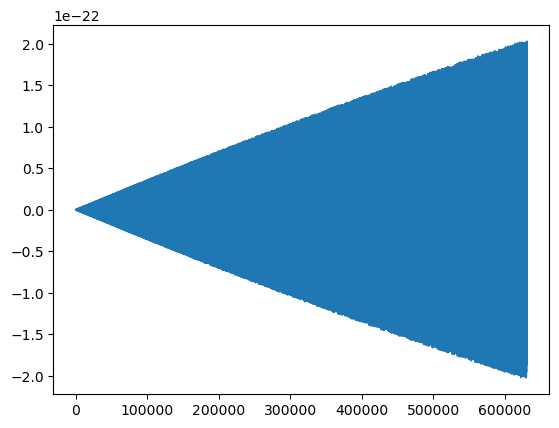

In [32]:
plt.plot((waveform_approx-waveform_true)[0].get())

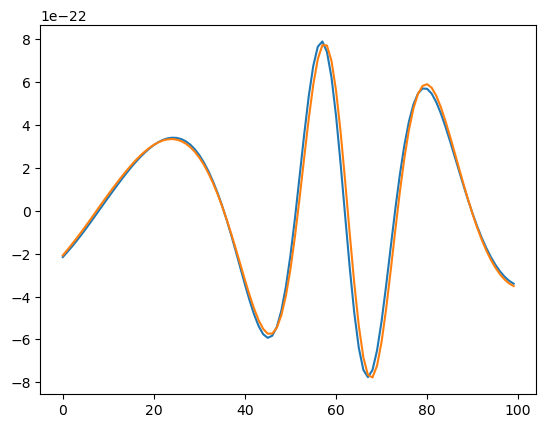

In [33]:
plt.plot((waveform_true)[0][-100:].get())
plt.plot((waveform_biased)[0][-100:].get())

In [34]:
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner=inner_product(waveform_biased,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_biased=np.sqrt(inner_product(waveform_biased,waveform_biased,PSD,dt,use_gpu=use_gpu))
diff_inner/((norm_true)*norm_biased)


np.float64(0.9936937158933525)

In [35]:
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
deviation_included=True
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0

deviation=biased_params-params_truth_in_considered

PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])

norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
delta = np.linspace(-1,1,500)
save_inner=[]
for i in range(len(delta)):
    biased = params_truth_in_considered + delta[i] * deviation
    dev_0_p= biased[9]
    dev_0_e= biased[10]
    add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
    add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,\
                    "deviation_included":deviation_included,"dev0p":dev_0_p,
        "dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

    pars_list = [np.exp(biased[0]), biased[1], biased[2], biased[3], \
             biased[4], xI0, dist, biased[5], biased[6], qK, phiK, biased[7], Phi_theta0,\
               biased[8]]
    waveform_considered = superkludge_wave_biased(*pars_list, *add_args, dt=dt, T=T,use_gpu=use_gpu)
    diff_inner=inner_product(waveform_considered,waveform_true,PSD,dt,use_gpu=use_gpu)
    norm_biased=np.sqrt(inner_product(waveform_considered,waveform_considered,PSD,dt,use_gpu=use_gpu))
    mismatch=diff_inner/((norm_true)*norm_biased)
   #print(mismatch)
    save_inner.append(mismatch)


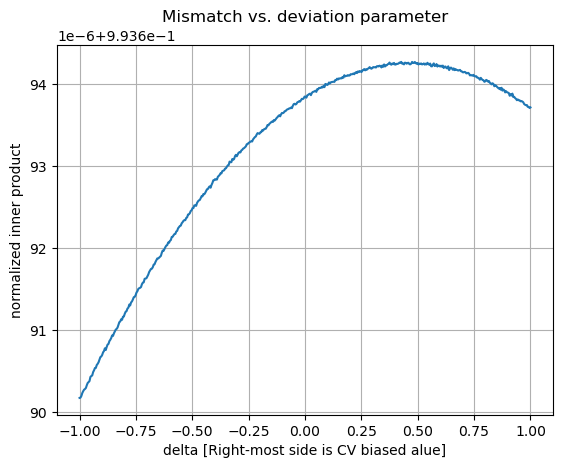

In [36]:
plt.plot(delta,save_inner)
plt.xlabel("delta [Right-most side is CV biased alue]")
plt.ylabel("normalized inner product")
plt.title("Mismatch vs. deviation parameter")
plt.grid(True)

In [37]:
print(np.max(save_inner))
delta[np.argmax(save_inner)]
#0.8587424254524265

0.9936942708751446


np.float64(0.42685370741482953)

In [38]:
print(np.max(save_inner))
delta[np.argmax(save_inner)]
#0.8587424254524265

0.9936942708751446


np.float64(0.42685370741482953)

In [39]:
print(np.max(save_inner))
delta[np.argmax(save_inner)]
#0.8587424254524265

0.9936942708751446


np.float64(0.42685370741482953)

# points
1. select mode to reduce noise
2. Discuss with Miaoxin

In [48]:
pars_list = [np.exp(1.38155486e+01), 9.99979446e+00, 8.00040917e-01, 7.49979221e+00, \
             3.99999719e-01, xI0, dist, 7.85405818e-01, 9.99994002e-01, qK, phiK, 8.99976505e-01, Phi_theta0,\
               3.99990964e-01]

waveform_paris = superkludge_wave_biased(*pars_list, *add_args, dt=dt, T=T)
add_args = [chi2, False, evolve_primary, evolve_2PA,deviation_included,2.65739624e-05,-6.02376376e-06,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner=inner_product(waveform_paris,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_biased=np.sqrt(inner_product(waveform_paris,waveform_paris,PSD,dt,use_gpu=use_gpu))
diff_inner/((norm_true)*norm_biased)

np.float64(0.999999707702163)